# 06 — Liquidity Sweeps

## Concept
Before major reversals, institutions sweep liquidity pooled at:
- Equal highs (retail buy-stops above resistance)
- Equal lows (retail sell-stops below support)

The sweep is a **wick** that goes through the level but CLOSES back.
It signals: 1) stops were taken, 2) now price can move the other way.

## Hypothesis
OBs preceded by a liquidity sweep in the same direction are higher quality:
- The sweep absorbs all the opposing orders
- The OB retest has less resistance to contend with
- Win rate should improve

## What we measure
- How often does a sweep precede a valid OB?
- Does adding sweep confirmation improve the quality metrics?

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from strategy.ob_core import add_candle_features
from strategy.liquidity.sweeps import (
    detect_liquidity_levels, detect_liquidity_sweeps, has_recent_sweep
)
from strategy.ob_signals import list_ob_signals_enhanced, OBSignalConfig, get_passed_signals

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (18, 7)})

SYMBOL = 'XAUUSDT'
RISK   = 20.0

m5 = pd.read_csv(f'../notebooks/data/{SYMBOL}/M5/ohlcv.csv', index_col=0, parse_dates=True)
if m5.index.tzinfo is None:
    m5.index = m5.index.tz_localize('UTC')
m5 = add_candle_features(m5.sort_index())

print(f'Loaded {len(m5):,} M5 bars')

Loaded 19,798 M5 bars


In [2]:
# ── Detect liquidity levels and sweeps ─────────────────────────────────────
levels = detect_liquidity_levels(m5, lookback=200, min_touches=2)
sweeps = detect_liquidity_sweeps(m5, levels, sweep_lookback=50)

bull_sweeps = [s for s in sweeps if s.direction == 'bullish_sweep']
bear_sweeps = [s for s in sweeps if s.direction == 'bearish_sweep']

print(f'Liquidity levels: {len(levels)}')
print(f'  Equal highs: {sum(1 for l in levels if l.kind == "high")}')
print(f'  Equal lows : {sum(1 for l in levels if l.kind == "low")}')
print(f'\nLiquidity sweeps: {len(sweeps)}')
print(f'  Bullish sweeps (low swept): {len(bull_sweeps)}')
print(f'  Bearish sweeps (high swept): {len(bear_sweeps)}')

Liquidity levels: 16
  Equal highs: 8
  Equal lows : 8

Liquidity sweeps: 6
  Bullish sweeps (low swept): 2
  Bearish sweeps (high swept): 4


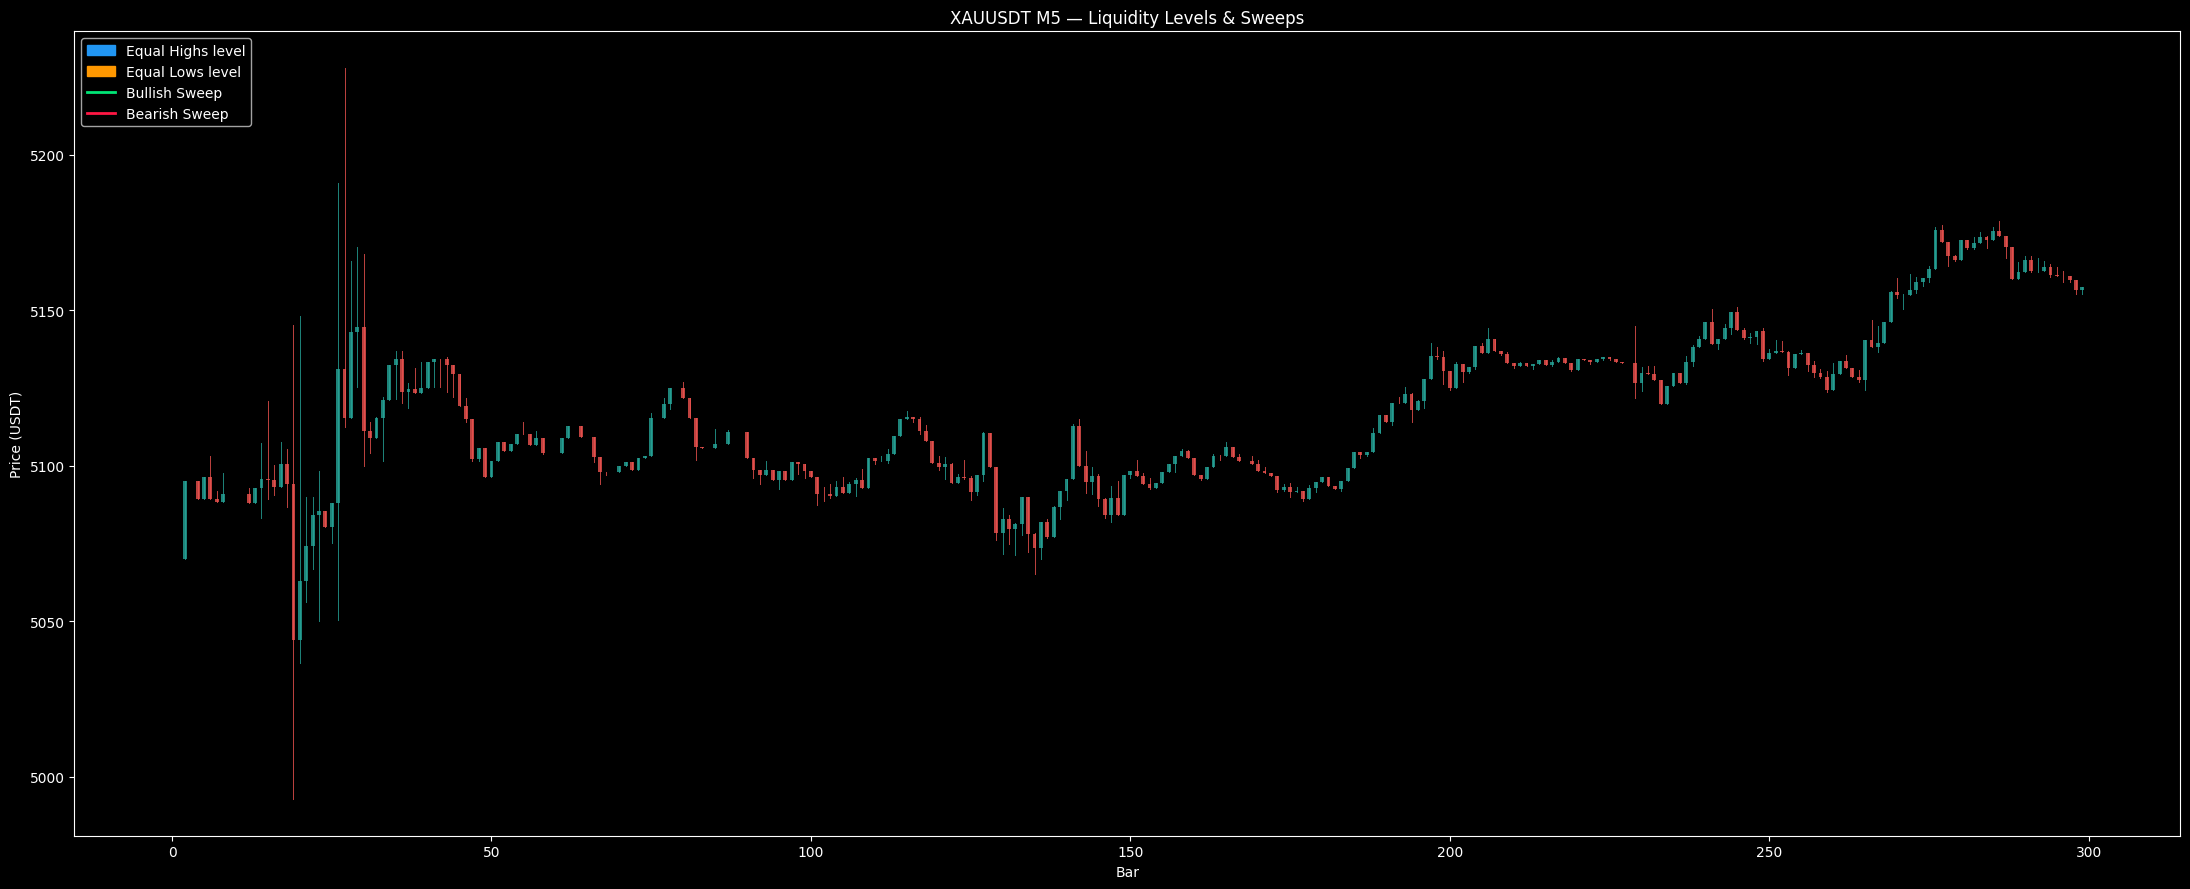

In [3]:
# ── Visualize on chart ─────────────────────────────────────────────────────
start, end = 0, 300
chart = m5.iloc[start:end]

fig, ax = plt.subplots(figsize=(22, 9))

for i, (ts, row) in enumerate(chart.iterrows()):
    color = '#26a69a' if row['close'] >= row['open'] else '#ef5350'
    ax.plot([i, i], [row['low'], row['high']], color=color, linewidth=0.7, alpha=0.8)
    ax.bar(i, abs(row['close']-row['open']), bottom=min(row['open'],row['close']),
           color=color, width=0.6, alpha=0.8)

# Draw equal-high/low zones
chart_levels = [l for l in levels if start <= l.last_idx < end]
for lev in chart_levels:
    color = '#2196F3' if lev.kind == 'high' else '#FF9800'
    first = max(lev.first_idx - start, 0)
    last  = min(lev.last_idx  - start, len(chart) - 1)
    ax.plot([first, last], [lev.price, lev.price],
            color=color, linewidth=1.5, linestyle='--', alpha=0.8)
    ax.text(last + 1, lev.price, f'{lev.touches}×', color=color, fontsize=8, va='center')

# Mark sweep bars
chart_sweeps = [s for s in sweeps if start <= s.sweep_bar_idx < end]
for s in chart_sweeps:
    local_i = s.sweep_bar_idx - start
    color   = '#00E676' if s.direction == 'bullish_sweep' else '#FF1744'
    ax.axvline(local_i, color=color, linewidth=2.0, alpha=0.9, linestyle='-')
    label = 'BULL SWEEP' if s.direction == 'bullish_sweep' else 'BEAR SWEEP'
    ax.text(local_i, chart['low'].min(), label, color=color, fontsize=7,
            rotation=90, va='bottom', ha='right')

handles = [
    mpatches.Patch(color='#2196F3', label='Equal Highs level'),
    mpatches.Patch(color='#FF9800', label='Equal Lows level'),
    plt.Line2D([0],[0], color='#00E676', linewidth=2, label='Bullish Sweep'),
    plt.Line2D([0],[0], color='#FF1744', linewidth=2, label='Bearish Sweep'),
]
ax.legend(handles=handles, loc='upper left')
ax.set_title(f'{SYMBOL} M5 — Liquidity Levels & Sweeps')
ax.set_xlabel('Bar')
ax.set_ylabel('Price (USDT)')
plt.tight_layout()
plt.show()

In [4]:
# ── Add sweep confirmation to OB signals ───────────────────────────────────
cfg_sweep = OBSignalConfig(rr=2.0, liquidity_sweep_filter=True,
                           sweep_lookback_bars=50, sweep_max_age_bars=30)
sigs_sweep = list_ob_signals_enhanced(m5, risk_cash=RISK, config=cfg_sweep)
sigs_sweep_pass = get_passed_signals(sigs_sweep)

cfg_base = OBSignalConfig(rr=2.0)
sigs_base = list_ob_signals_enhanced(m5, risk_cash=RISK, config=cfg_base)

print(f'Baseline signals: {len(sigs_base)}')
print(f'Sweep-confirmed : {len(sigs_sweep_pass)}')
pct = (1 - len(sigs_sweep_pass) / max(len(sigs_base), 1)) * 100
print(f'Reduction       : {pct:.1f}%')
print('\nSweep confirmation is OPTIONAL — use it only if backtest shows improvement.')

Baseline signals: 290
Sweep-confirmed : 0
Reduction       : 100.0%

Sweep confirmation is OPTIONAL — use it only if backtest shows improvement.
